In [28]:
import numpy as np
import os
import PIL
import PIL.Image
import tensorflow as tf
import tensorflow_datasets as tfds
import pathlib
import matplotlib.pyplot as plt

In [29]:
dataset_path = os.path.join('datasets', 'flower-photos')
data_dir = pathlib.Path(dataset_path).with_suffix('')

In [30]:
image_count = len(list(data_dir.glob('*/*.jpg')))
image_count

2746

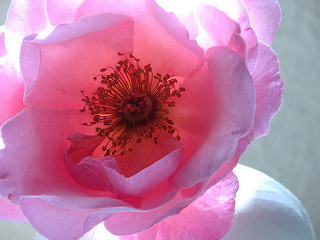

In [31]:
rose = list(data_dir.glob('rose/*'))
PIL.Image.open(str(rose[0]))

In [32]:
batch_size = 32
img_size = (180, 180)

In [33]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset='training',
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

Found 2746 files belonging to 5 classes.
Using 2197 files for training.


In [34]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset='validation',
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

Found 2746 files belonging to 5 classes.
Using 549 files for validation.


In [35]:
class_names = train_ds.class_names
class_names

['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']

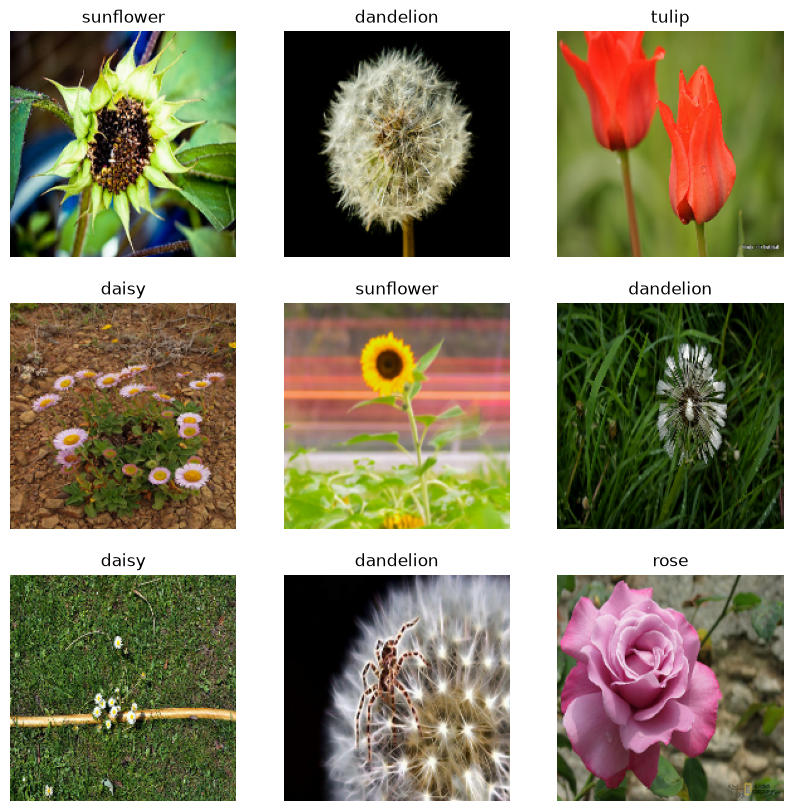

In [36]:
os.environ['KMP_DUPLICATE_LTB_OK'] = 'True'
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i]])
        plt.axis('off')

In [37]:
for image_batch, label_batch in train_ds:
    print(image_batch.shape)
    print(label_batch.shape)
    break

(32, 180, 180, 3)
(32,)


In [38]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

In [39]:
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, label_batch = next(iter(normalized_ds))
first_image = image_batch[0]
print(np.min(first_image), np.max(first_image))

0.046892848 0.94968975


In [40]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [41]:
num_classes = 5
model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./ 255),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(num_classes)
])

In [42]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [43]:
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10


I0000 00:00:1783621202.214980  156483 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_8791__.37


67/69 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.4086 - loss: 1.3628

I0000 00:00:1783621206.231852  156477 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_8791__.37


69/69 ━━━━━━━━━━━━━━━━━━━━ 7s 79ms/step - accuracy: 0.4124 - loss: 1.3578 - val_accuracy: 0.4954 - val_loss: 1.1252
Epoch 2/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.5812 - loss: 1.0602 - val_accuracy: 0.5920 - val_loss: 1.0183
Epoch 3/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.6472 - loss: 0.9188 - val_accuracy: 0.6011 - val_loss: 0.9875
Epoch 4/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.7087 - loss: 0.7685 - val_accuracy: 0.6047 - val_loss: 1.0237
Epoch 5/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.7883 - loss: 0.5740 - val_accuracy: 0.6284 - val_loss: 1.0898
Epoch 6/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.8471 - loss: 0.4347 - val_accuracy: 0.6430 - val_loss: 1.1074
Epoch 7/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.8858 - loss: 0.3414 - val_accuracy: 0.5628 - val_loss: 1.7383
Epoch 8/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.8930 - loss: 0.2945 - val_accuracy: 0.6029 - val_loss: 1.

Second Way

In [44]:
list_ds = tf.data.Dataset.list_files(str(data_dir/'*/*'), shuffle=False)
list_ds = list_ds.shuffle(image_count, reshuffle_each_iteration=False)

In [45]:
for f in list_ds.take(5):
    print(f.numpy())

b'datasets/flower-photos/dandelion/15219268336_f2460fca88_m.jpg'
b'datasets/flower-photos/sunflower/22183521655_56221bf2a4_n.jpg'
b'datasets/flower-photos/daisy/8742143296_fed9fa007c.jpg'
b'datasets/flower-photos/dandelion/7295618968_c08a326cc1_m.jpg'
b'datasets/flower-photos/daisy/9346508462_f0af3163f4.jpg'


In [46]:
class_names = np.array(sorted([item.name for item in data_dir.glob('*') if item.name != "LICENSE.txt"]))
print(class_names)

['daisy' 'dandelion' 'rose' 'sunflower' 'tulip']


In [47]:
val_size = int(image_count * 0.2)
train_ds = list_ds.skip(val_size)
val_ds = list_ds.take(val_size)

In [48]:
print(tf.data.experimental.cardinality(train_ds).numpy())
print(tf.data.experimental.cardinality(val_ds).numpy())

2197
549


In [49]:
def get_label(file_path):
    parts = tf.strings.split(file_path, os.path.sep)
    one_hot = parts[-2] == class_names
    return tf.argmax(one_hot)

In [50]:
def decode_img(img):
    img = tf.io.decode_jpeg(img, channels=3)
    return tf.image.resize(img, img_size)

In [51]:
def process_path(file_path):
    label = get_label(file_path)
    img = tf.io.read_file(file_path)
    img = decode_img(img)
    return img, label

In [52]:
train_ds = train_ds.map(process_path, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.map(process_path, num_parallel_calls=AUTOTUNE)

In [53]:
for image, label in train_ds.take(1):
    print('Image shape: ', image.numpy().shape)
    print('Label: ', label.numpy())

Image shape:  (180, 180, 3)
Label:  1


In [54]:
def configure_for_performance(ds):
    ds = ds.cache()
    ds = ds.shuffle(buffer_size=1000)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(buffer_size=AUTOTUNE)
    return ds

train_ds = configure_for_performance(train_ds)
val_ds = configure_for_performance(val_ds)

W0000 00:00:1783621234.545674  156379 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


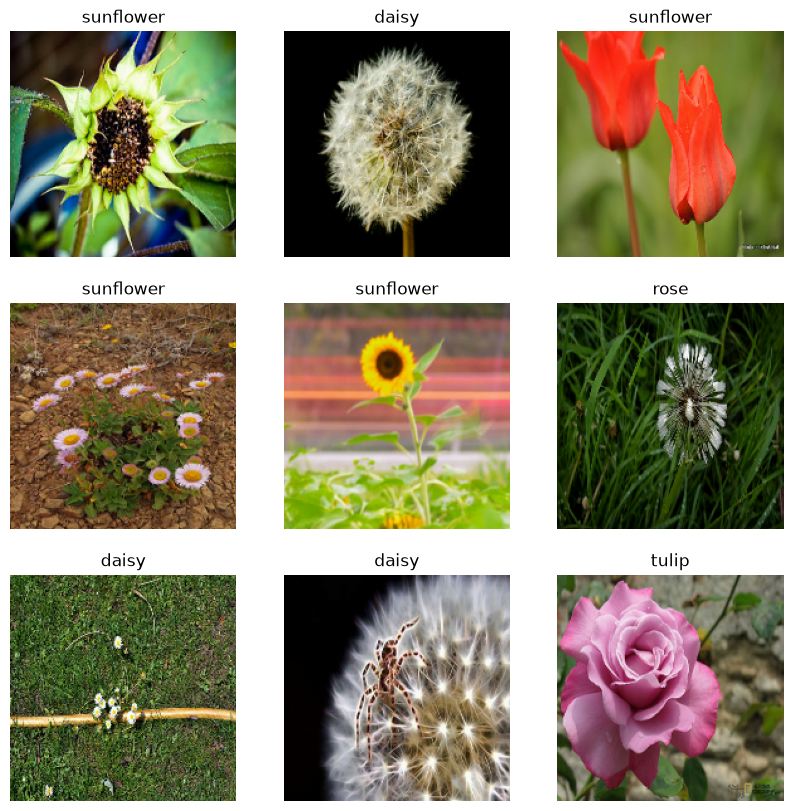

In [55]:
image_batch, label_batch = next(iter(train_ds))

plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype('uint8'))
    label = label_batch[i]
    plt.title(class_names[label])
    plt.axis('off')

Try once with a kernel restart and once without a kernel restart. After restart kernel, don't run model.fit in upper column.

Without restart\
val_accuracy = 89.98

With restart\
val_accuracy = 64.85

In [56]:
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10


I0000 00:00:1783621235.586103  156477 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_13686__.37


67/69 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8955 - loss: 0.4049

I0000 00:00:1783621239.494170  156480 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_13686__.37


69/69 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.8967 - loss: 0.4022 - val_accuracy: 0.9053 - val_loss: 0.3363
Epoch 2/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.9677 - loss: 0.1284 - val_accuracy: 0.9162 - val_loss: 0.3501
Epoch 3/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.9813 - loss: 0.0621 - val_accuracy: 0.8962 - val_loss: 0.4285
Epoch 4/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.9909 - loss: 0.0412 - val_accuracy: 0.8944 - val_loss: 0.4558
Epoch 5/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.9932 - loss: 0.0266 - val_accuracy: 0.8889 - val_loss: 0.4925
Epoch 6/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.9964 - loss: 0.0186 - val_accuracy: 0.8907 - val_loss: 0.5438
Epoch 7/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.9977 - loss: 0.0146 - val_accuracy: 0.8962 - val_loss: 0.5266
Epoch 8/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.9986 - loss: 0.0122 - val_accuracy: 0.8834 - val_loss: 0.